### Sync Data

In [ ]:
!rsync -av /content/drive/MyDrive/DLCV_split/ /content/DLCV_split/

### List Data

In [ ]:
!ls /content/DLCV_split

### Write YAML Config

In [ ]:
%%writefile /content/script_data.yaml
# Absolute path to the unzipped dataset in Colab
path: /content/DLCV_split


train: train/images
val: test/images


names:
  0: assamese
  1: bengali
  2: devanagari
  3: gujarati
  4: gurmukhi
  5: kannada
  6: latin
  7: malayalam
  8: odia
  9: tamil
  10: telugu

### Train Model

In [ ]:
import os

# 1. Install the YOLOv8 library
!pip install ultralytics -q

# 2. Run the Python training script
from ultralytics import YOLO

# Load a pre-trained YOLOv8 'small' model (a great balance of speed and accuracy)
model = YOLO('yolov8s.pt')

# Start training
results = model.train(
    data='/content/script_data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,

    # --- CRITICAL FOR SCRIPT DETECTION ---
    fliplr=0.0,
    flipud=0.0,
    degrees=2.0,

    project='/content/drive/MyDrive/YOLO_Text_Models',
    name='script_detector_run1'
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/script_data.yaml, degrees=2.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=script_detector_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108576768 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


val: Scanning /content/drive/.shortcut-targets-by-id/1URoYWSnojcbvFIJPv3aywBb0lT1JVlCo/DLCV_split/test/labels... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 2.9it/s 1:28
val: New cache created: /content/drive/.shortcut-targets-by-id/1URoYWSnojcbvFIJPv3aywBb0lT1JVlCo/DLCV_split/test/labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /content/drive/MyDrive/YOLO_Text_Models/script_detector_run1/labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/YOLO_Text_Models/script_detector_run1
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50       3.8G      1.818      4.709      1.392 

### Load Results CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


results_path = '/content/drive/MyDrive/YOLO_Text_Models/script_detector_run1/results.csv'


results_df = pd.read_csv(results_path)


results_df.columns = results_df.columns.str.replace('# ', '', regex=False).str.strip()

print("Results DataFrame head:")
display(results_df.head())
print("Results DataFrame columns:")
print(results_df.columns)

Results DataFrame head:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,147.162,1.81792,4.70926,1.39153,0.32433,0.21105,0.14237,0.08638,1.43496,2.37039,1.13985,0.000220,0.000220,0.000220
1,2,272.885,1.47386,2.23045,1.16856,0.39856,0.25788,0.21999,0.12945,1.44970,2.04870,1.16171,0.000434,0.000434,0.000434
2,3,402.954,1.46516,2.01004,1.15696,0.41848,0.27144,0.23357,0.13613,1.43382,2.06270,1.19791,0.000639,0.000639,0.000639
3,4,537.166,1.43855,1.83649,1.14092,0.51029,0.28104,0.24031,0.14875,1.46605,1.94683,1.21030,0.000627,0.000627,0.000627
4,5,671.018,1.43152,1.78148,1.14784,0.38346,0.35283,0.29060,0.17775,1.38899,1.84995,1.14979,0.000614,0.000614,0.000614


Results DataFrame columns:
Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


### Plot Training Metrics

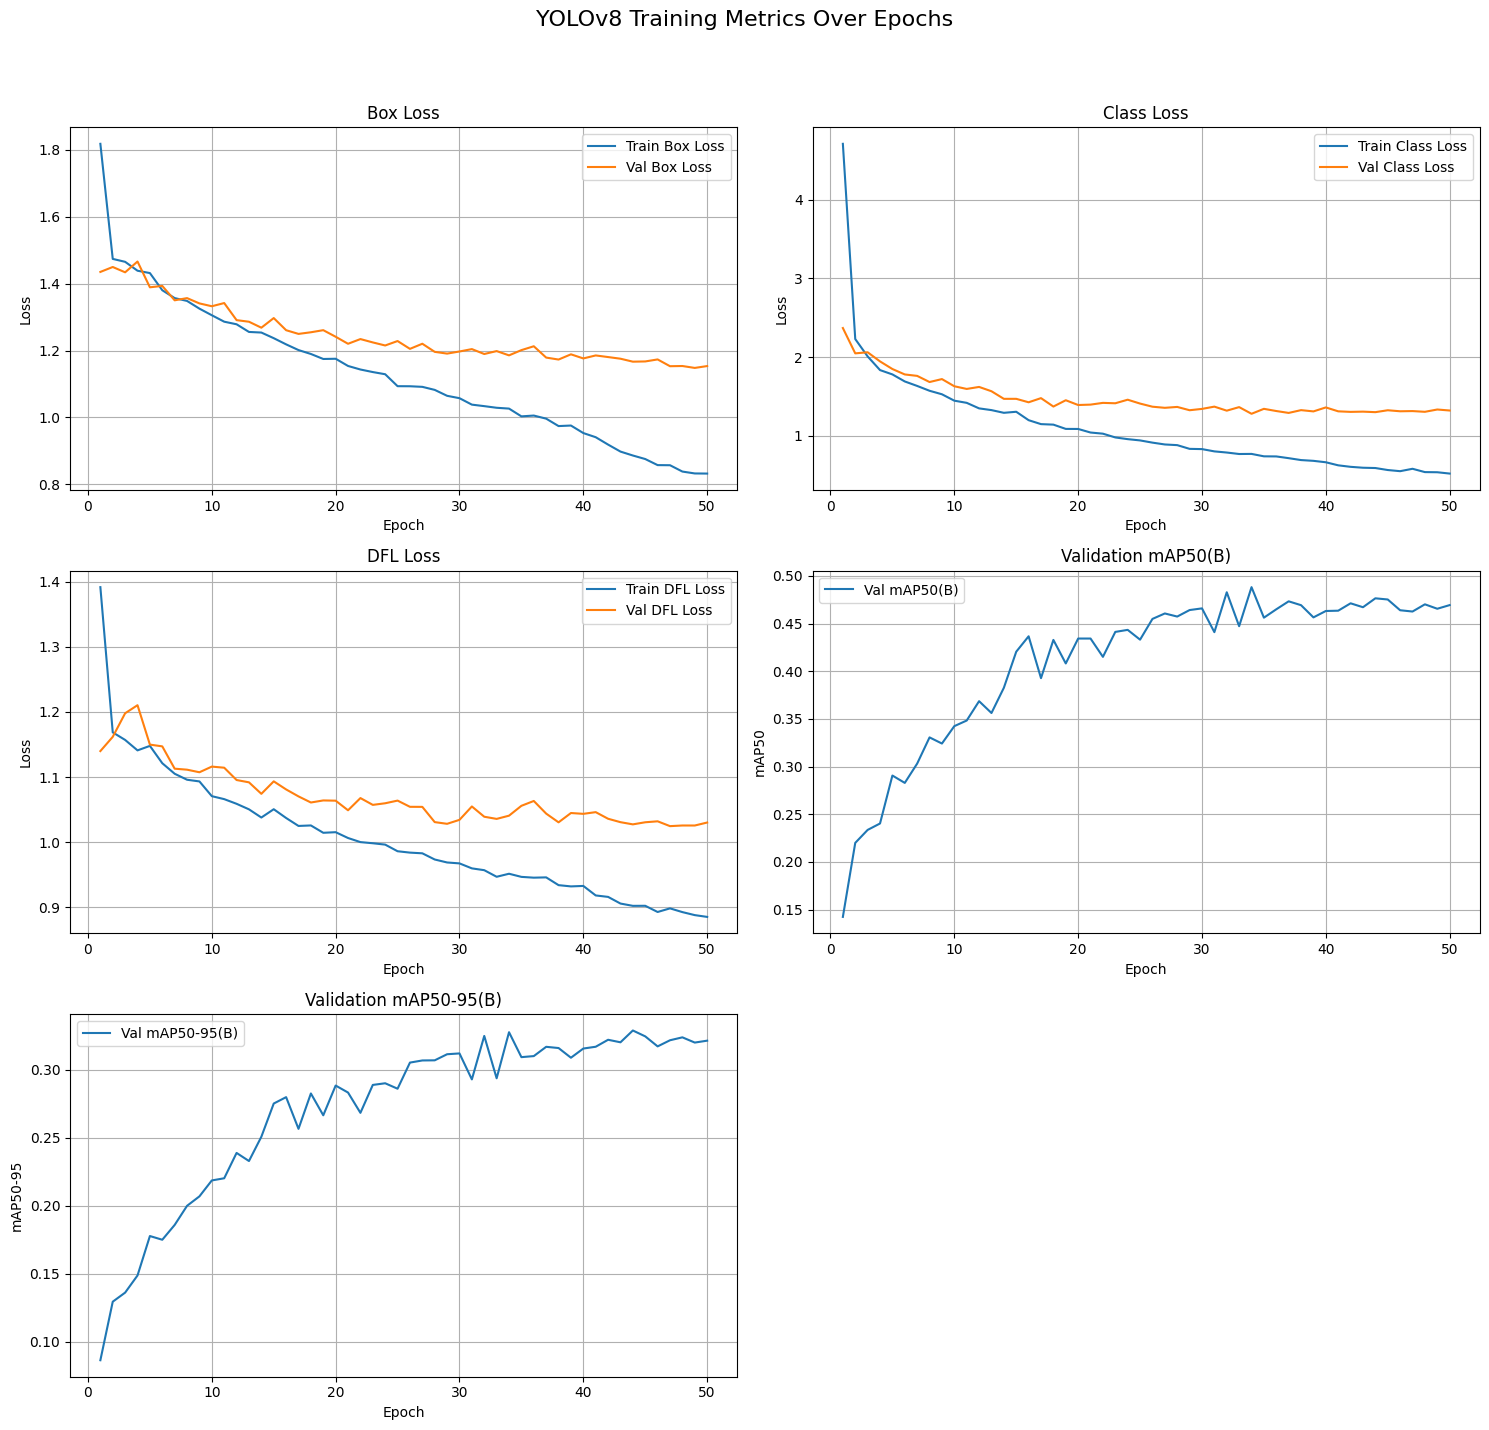

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('YOLOv8 Training Metrics Over Epochs', fontsize=16)

# Plot Box Loss
axes[0, 0].plot(results_df['epoch'], results_df['train/box_loss'], label='Train Box Loss')
axes[0, 0].plot(results_df['epoch'], results_df['val/box_loss'], label='Val Box Loss')
axes[0, 0].set_title('Box Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot Class Loss
axes[0, 1].plot(results_df['epoch'], results_df['train/cls_loss'], label='Train Class Loss')
axes[0, 1].plot(results_df['epoch'], results_df['val/cls_loss'], label='Val Class Loss')
axes[0, 1].set_title('Class Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot DFL Loss
axes[1, 0].plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train DFL Loss')
axes[1, 0].plot(results_df['epoch'], results_df['val/dfl_loss'], label='Val DFL Loss')
axes[1, 0].set_title('DFL Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot mAP50
axes[1, 1].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='Val mAP50(B)')
axes[1, 1].set_title('Validation mAP50(B)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('mAP50')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Plot mAP50-95
axes[2, 0].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='Val mAP50-95(B)')
axes[2, 0].set_title('Validation mAP50-95(B)')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('mAP50-95')
axes[2, 0].legend()
axes[2, 0].grid(True)

# Hide the unused subplot
fig.delaxes(axes[2, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Predict Image

In [ ]:
from ultralytics import YOLO

# Load YOUR newly trained model
# (Check your Google Drive folder for the exact path to best.pt)
my_model = YOLO('/content/drive/MyDrive/YOLO_Text_Models/script_detector_run1/weights/best.pt')

# Run prediction on a test image
results = my_model.predict(
    source='/content/drive/MyDrive/DLCV_split/val/images/image_01675.jpg', # Put a specific image name here
    conf=0.4,       # Only show predictions it is 40%+ confident about
    rect=True,      # Good for rectangular scene images
    save=True,
    line_width=3 # Saves the output image with boxes drawn on it
)

# Display the resulting image inside Colab
from IPython.display import Image
Image(filename=results[0].save_dir + '/image_01675.jpg')